# Catalogue-selection sensitivity: editorial versus systematic top-ten bands

## tl;dr

This experiment changes the band-selection rule while holding the audience
metric, population denominator and ten-band catalogue size fixed where the
frozen data allow it.

For the eight eligible Functional Urban Areas, **67 of 80 selections
(83.8%)** overlap between the editorial catalogue and a systematic catalogue
containing each area's ten most-listened mapped bands from the popularity-first
top 1,000. Even with that turnover, the primary index has a rank correlation of
**1.000**: all eight primary ranks are unchanged. The dominant-band-excluded
comparison is slightly less stable, with a rank correlation of **0.976**.

Bristol and Leicester are excluded from the matched ranking because the mapped
top-1,000 pool contains only eight and two bands for them. That coverage gap is
part of the result.


## Context and methods

The final study gives every FUA ten editorially reviewed bands. That controls
catalogue size, but it does not make those catalogues representative. This
follow-up asks a narrower question: **does the ranking change when the same
number of bands is chosen by a reproducible popularity rule?**

The alternative catalogue takes the ten bands with the largest frozen monthly-
listener counts in each FUA from the mapped popularity-first top-1,000 pool.
The comparison keeps only FUAs with at least ten mapped candidates, then holds
constant:

- the ten-band catalogue size;
- the July 18, 2026 Spotify snapshot;
- the 2024 OECD Functional Urban Area population;
- current global monthly listeners as the audience metric; and
- formation-place-to-FUA mapping using strict and reviewed-extended mappings.

### Assumptions

- The popularity-first top-1,000 pool is a systematic alternative, not a census
  or random sample of UK bands.
- The two Spotify captures are 5 minutes 22 seconds apart; all 84 identities
  present in both source files have identical monthly-listener values.
- The reported `global_attention_population_index` is the sum of artist-level
  global monthly-listener counts divided by local FUA population. It is a
  comparative index, not a local listening rate or a historical productivity
  measure.
- Spotify defines monthly listeners as total listeners in the previous 28 days,
  including active and programmed listening. A person who listened to several
  selected bands can appear in several artist totals. See
  [Spotify's definition](https://support.spotify.com/na-en/artists/article/audience-segments/).
- Removing the largest band is labelled **dominant-band sensitivity within the
  selected catalogue**, not scene depth.


## Data

Load and validate the four frozen inputs.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "src/python_uk_bands").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository")


ROOT = find_project_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from python_uk_bands.config import FINAL_STUDY_BAND_METRICS_PATH
from python_uk_bands.visuals import HOUSE, apply_chart_style

SNAPSHOT_DATE = "2026-07-18"
EDITORIAL_PATH = FINAL_STUDY_BAND_METRICS_PATH
POPULARITY_PATH = ROOT / "data/processed/popularity_first_top1000_20260718T204522Z_bands.csv"
MAPPING_PATH = ROOT / "data/interim/popularity_first_top1000_20260718T204522Z_fua_mapping_audit.csv"
POPULATION_PATH = ROOT / "data/processed/uk_fua_population_2024_20260830T221015Z.csv"
ARTIFACT_DIR = ROOT / "artifacts/experiments/catalogue_selection_sensitivity/20260718T204522Z"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

editorial = pd.read_csv(EDITORIAL_PATH, keep_default_na=False)
popularity = pd.read_csv(POPULARITY_PATH, keep_default_na=False)
mapping = pd.read_csv(MAPPING_PATH, keep_default_na=False)
population = (
    pd.read_csv(POPULATION_PATH, keep_default_na=False)
    .sort_values("uk_population_rank")
    .head(10)
    .reset_index(drop=True)
)

assert len(editorial) == 100
assert editorial["spotify_id"].nunique() == 100
assert editorial.groupby("fua_code").size().eq(10).all()
assert popularity["returned_spotify_id"].is_unique
assert mapping["returned_spotify_id"].is_unique
assert population["fua_code"].is_unique
assert editorial["stats_extracted_at_utc"].str.startswith(SNAPSHOT_DATE).all()
assert popularity["stats_extracted_at_utc"].str.startswith(SNAPSHOT_DATE).all()

shared_values = editorial[["spotify_id", "monthly_listeners"]].merge(
    popularity[["returned_spotify_id", "monthly_listeners"]],
    left_on="spotify_id",
    right_on="returned_spotify_id",
    suffixes=("_editorial", "_popularity_first"),
    validate="one_to_one",
)
assert len(shared_values) == 85
assert shared_values["monthly_listeners_editorial"].equals(
    shared_values["monthly_listeners_popularity_first"]
)

source_audit = pd.DataFrame(
    {
        "Input": ["Editorial catalogue", "Popularity-first pool", "FUA mapping", "Population universe"],
        "Rows": [len(editorial), len(popularity), len(mapping), len(population)],
        "Grain": ["band–FUA", "band", "band", "FUA"],
        "Source": [str(path.relative_to(ROOT)) for path in [EDITORIAL_PATH, POPULARITY_PATH, MAPPING_PATH, POPULATION_PATH]],
    }
)
display(source_audit)


,Input,Rows,Grain,Source
0,Editorial catalogue,100,band–FUA,data/processed/fua_top10_band_metrics_20260718...
1,Popularity-first pool,1000,band,data/processed/popularity_first_top1000_202607...
2,FUA mapping,1000,band,data/interim/popularity_first_top1000_20260718...
3,Population universe,10,FUA,data/processed/uk_fua_population_2024_20260830...


### Candidate coverage

An FUA needs at least ten mapped candidates for an equal-count comparison.
Coverage is reported before any FUA is excluded.


In [2]:
mapped_candidates = popularity[
    ["returned_spotify_id", "spotify_name", "monthly_listeners", "followers"]
].merge(
    mapping[["returned_spotify_id", "mapping_tier", "fua_code", "study_city_label"]],
    on="returned_spotify_id",
    how="left",
    validate="one_to_one",
)
mapped_candidates = mapped_candidates.loc[
    mapped_candidates["mapping_tier"].isin({"strict", "reviewed_extended"})
    & mapped_candidates["fua_code"].isin(population["fua_code"])
].merge(
    population[["fua_code", "population"]],
    on="fua_code",
    how="left",
    validate="many_to_one",
)
assert not mapped_candidates["population"].isna().any()
assert not mapped_candidates.duplicated("returned_spotify_id").any()

eligibility = population[
    ["uk_population_rank", "fua_code", "study_city_label", "population"]
].merge(
    mapped_candidates.groupby("fua_code", as_index=False).agg(
        mapped_candidates=("returned_spotify_id", "nunique")
    ),
    on="fua_code",
    how="left",
    validate="one_to_one",
)
eligibility["mapped_candidates"] = eligibility["mapped_candidates"].fillna(0).astype(int)
eligibility["matched_comparison_eligible"] = eligibility["mapped_candidates"].ge(10)
assert eligibility["matched_comparison_eligible"].sum() == 8
eligibility.to_csv(ARTIFACT_DIR / "eligibility.csv", index=False)
display(eligibility)


,uk_population_rank,fua_code,study_city_label,population,mapped_candidates,matched_comparison_eligible
0,1,UK001F,London,12666099,309,True
1,2,UK008F,Manchester,3595966,54,True
2,3,UK002F,Birmingham,3247941,27,True
3,4,UK003F,Leeds,3070506,26,True
4,5,UK004F,Glasgow,1895840,29,True
5,6,UK006F,Liverpool,1597536,37,True
6,7,UK013F,Newcastle,1221203,10,True
7,8,UK010F,Sheffield,1217504,22,True
8,9,UK011F,Bristol,1025309,8,False
9,10,UK014F,Leicester,967988,2,False


## Results

### 1. Build the matched catalogues

For each eligible FUA, compare the ten editorial selections with the ten mapped
bands having the largest monthly-listener counts in the popularity-first pool.


In [3]:
eligible_codes = set(
    eligibility.loc[eligibility["matched_comparison_eligible"], "fua_code"]
)

systematic = (
    mapped_candidates.loc[mapped_candidates["fua_code"].isin(eligible_codes)]
    .sort_values(
        ["study_city_label", "monthly_listeners", "spotify_name"],
        ascending=[True, False, True],
    )
    .groupby("study_city_label", sort=False)
    .head(10)
    .rename(columns={"returned_spotify_id": "spotify_id", "spotify_name": "band"})
)
systematic["catalogue"] = "Systematic popularity-first top ten"

editorial_matched = editorial.loc[editorial["fua_code"].isin(eligible_codes), [
    "fua_code", "study_city_label", "population", "spotify_id", "band", "monthly_listeners"
]].copy()
editorial_matched["catalogue"] = "Editorial reviewed ten"

selected = pd.concat(
    [
        editorial_matched,
        systematic[["fua_code", "study_city_label", "population", "spotify_id", "band", "monthly_listeners", "catalogue"]],
    ],
    ignore_index=True,
)
assert len(selected) == 160
assert selected.groupby(["catalogue", "fua_code"]).size().eq(10).all()
assert not selected.duplicated(["catalogue", "fua_code", "spotify_id"]).any()

overlap = []
for fua_code, group in selected.groupby("fua_code"):
    editorial_ids = set(group.loc[group["catalogue"].eq("Editorial reviewed ten"), "spotify_id"])
    systematic_ids = set(group.loc[group["catalogue"].eq("Systematic popularity-first top ten"), "spotify_id"])
    overlap.append(
        {
            "fua_code": fua_code,
            "selection_overlap": len(editorial_ids & systematic_ids),
            "selection_overlap_share": len(editorial_ids & systematic_ids) / 10,
        }
    )
overlap = pd.DataFrame(overlap)
assert overlap["selection_overlap"].between(0, 10).all()
selected.to_csv(ARTIFACT_DIR / "selected_bands.csv", index=False)
display(
    eligibility.loc[eligibility["matched_comparison_eligible"], ["fua_code", "study_city_label"]]
    .merge(overlap, on="fua_code", validate="one_to_one")
    .sort_values(["selection_overlap", "study_city_label"], ascending=[False, True])
)


,fua_code,study_city_label,selection_overlap,selection_overlap_share
4,UK004F,Glasgow,10,1.0
5,UK006F,Liverpool,10,1.0
7,UK010F,Sheffield,10,1.0
2,UK002F,Birmingham,9,0.9
1,UK008F,Manchester,8,0.8
3,UK003F,Leeds,7,0.7
0,UK001F,London,7,0.7
6,UK013F,Newcastle,6,0.6


### 2. Compare the attention/population index and dominant-band sensitivity

The primary index divides each catalogue's summed artist-level global monthly
listeners by FUA population. The second index removes that catalogue's largest
band before the same division.


In [4]:
summary = (
    selected.groupby(["catalogue", "fua_code", "study_city_label"], as_index=False)
    .agg(
        population=("population", "first"),
        selected_bands=("spotify_id", "nunique"),
        global_monthly_listener_sum=("monthly_listeners", "sum"),
        dominant_band_monthly_listeners=("monthly_listeners", "max"),
    )
)
summary["global_attention_population_index"] = (
    summary["global_monthly_listener_sum"] / summary["population"]
)
summary["dominant_band_share"] = (
    summary["dominant_band_monthly_listeners"] / summary["global_monthly_listener_sum"]
)
summary["dominant_band_excluded_index"] = (
    summary["global_monthly_listener_sum"] - summary["dominant_band_monthly_listeners"]
) / summary["population"]
summary["index_rank"] = summary.groupby("catalogue")[
    "global_attention_population_index"
].rank(method="min", ascending=False).astype(int)
summary["dominant_band_excluded_rank"] = summary.groupby("catalogue")[
    "dominant_band_excluded_index"
].rank(method="min", ascending=False).astype(int)

editorial_summary = summary.loc[summary["catalogue"].eq("Editorial reviewed ten")].drop(columns="catalogue")
systematic_summary = summary.loc[summary["catalogue"].eq("Systematic popularity-first top ten")].drop(columns="catalogue")
comparison = editorial_summary.merge(
    systematic_summary,
    on=["fua_code", "study_city_label", "population", "selected_bands"],
    suffixes=("_editorial", "_systematic"),
    validate="one_to_one",
).merge(overlap, on="fua_code", validate="one_to_one")
comparison["index_rank_change"] = comparison["index_rank_systematic"] - comparison["index_rank_editorial"]
comparison["dominant_band_excluded_rank_change"] = (
    comparison["dominant_band_excluded_rank_systematic"]
    - comparison["dominant_band_excluded_rank_editorial"]
)

primary_rank_correlation = comparison["index_rank_editorial"].corr(
    comparison["index_rank_systematic"]
)
excluded_rank_correlation = comparison["dominant_band_excluded_rank_editorial"].corr(
    comparison["dominant_band_excluded_rank_systematic"]
)
assert -1 <= primary_rank_correlation <= 1
assert -1 <= excluded_rank_correlation <= 1
assert set(comparison.loc[comparison["index_rank_editorial"].le(4), "study_city_label"]) == {
    "Sheffield", "Liverpool", "Manchester", "London"
}
assert set(comparison.loc[comparison["index_rank_systematic"].le(4), "study_city_label"]) == {
    "Sheffield", "Liverpool", "Manchester", "London"
}

comparison = comparison.sort_values("index_rank_editorial").reset_index(drop=True)
comparison.to_csv(ARTIFACT_DIR / "catalogue_comparison.csv", index=False)

display(Markdown(
    f"**Primary rank correlation:** {primary_rank_correlation:.3f}  \n**Dominant-band-excluded rank correlation:** {excluded_rank_correlation:.3f}"
))
display(comparison[[
    "study_city_label",
    "selection_overlap",
    "global_attention_population_index_editorial",
    "global_attention_population_index_systematic",
    "index_rank_editorial",
    "index_rank_systematic",
    "dominant_band_share_editorial",
    "dominant_band_share_systematic",
    "dominant_band_excluded_rank_editorial",
    "dominant_band_excluded_rank_systematic",
]])


**Primary rank correlation:** 1.000  
**Dominant-band-excluded rank correlation:** 0.976

,study_city_label,selection_overlap,global_attention_population_index_editorial,global_attention_population_index_systematic,index_rank_editorial,index_rank_systematic,dominant_band_share_editorial,dominant_band_share_systematic,dominant_band_excluded_rank_editorial,dominant_band_excluded_rank_systematic
0,Sheffield,10,76.924648,76.924648,1,1,0.558446,0.558446,1,1
1,Liverpool,10,45.001806,45.001806,2,2,0.527564,0.527564,3,4
2,Manchester,8,38.564537,41.148510,3,3,0.286108,0.268141,2,2
3,London,7,28.487875,33.766960,4,4,0.255062,0.215186,4,3
4,Birmingham,9,25.788163,25.921595,5,5,0.218852,0.217725,5,5
5,Glasgow,10,23.269592,23.269592,6,6,0.244988,0.244988,6,6
6,Newcastle,6,13.266590,13.250791,7,7,0.760705,0.761612,8,8
7,Leeds,7,8.989494,8.340415,8,8,0.293850,0.316719,7,7


### 3. Rank movement under the alternative selection rule

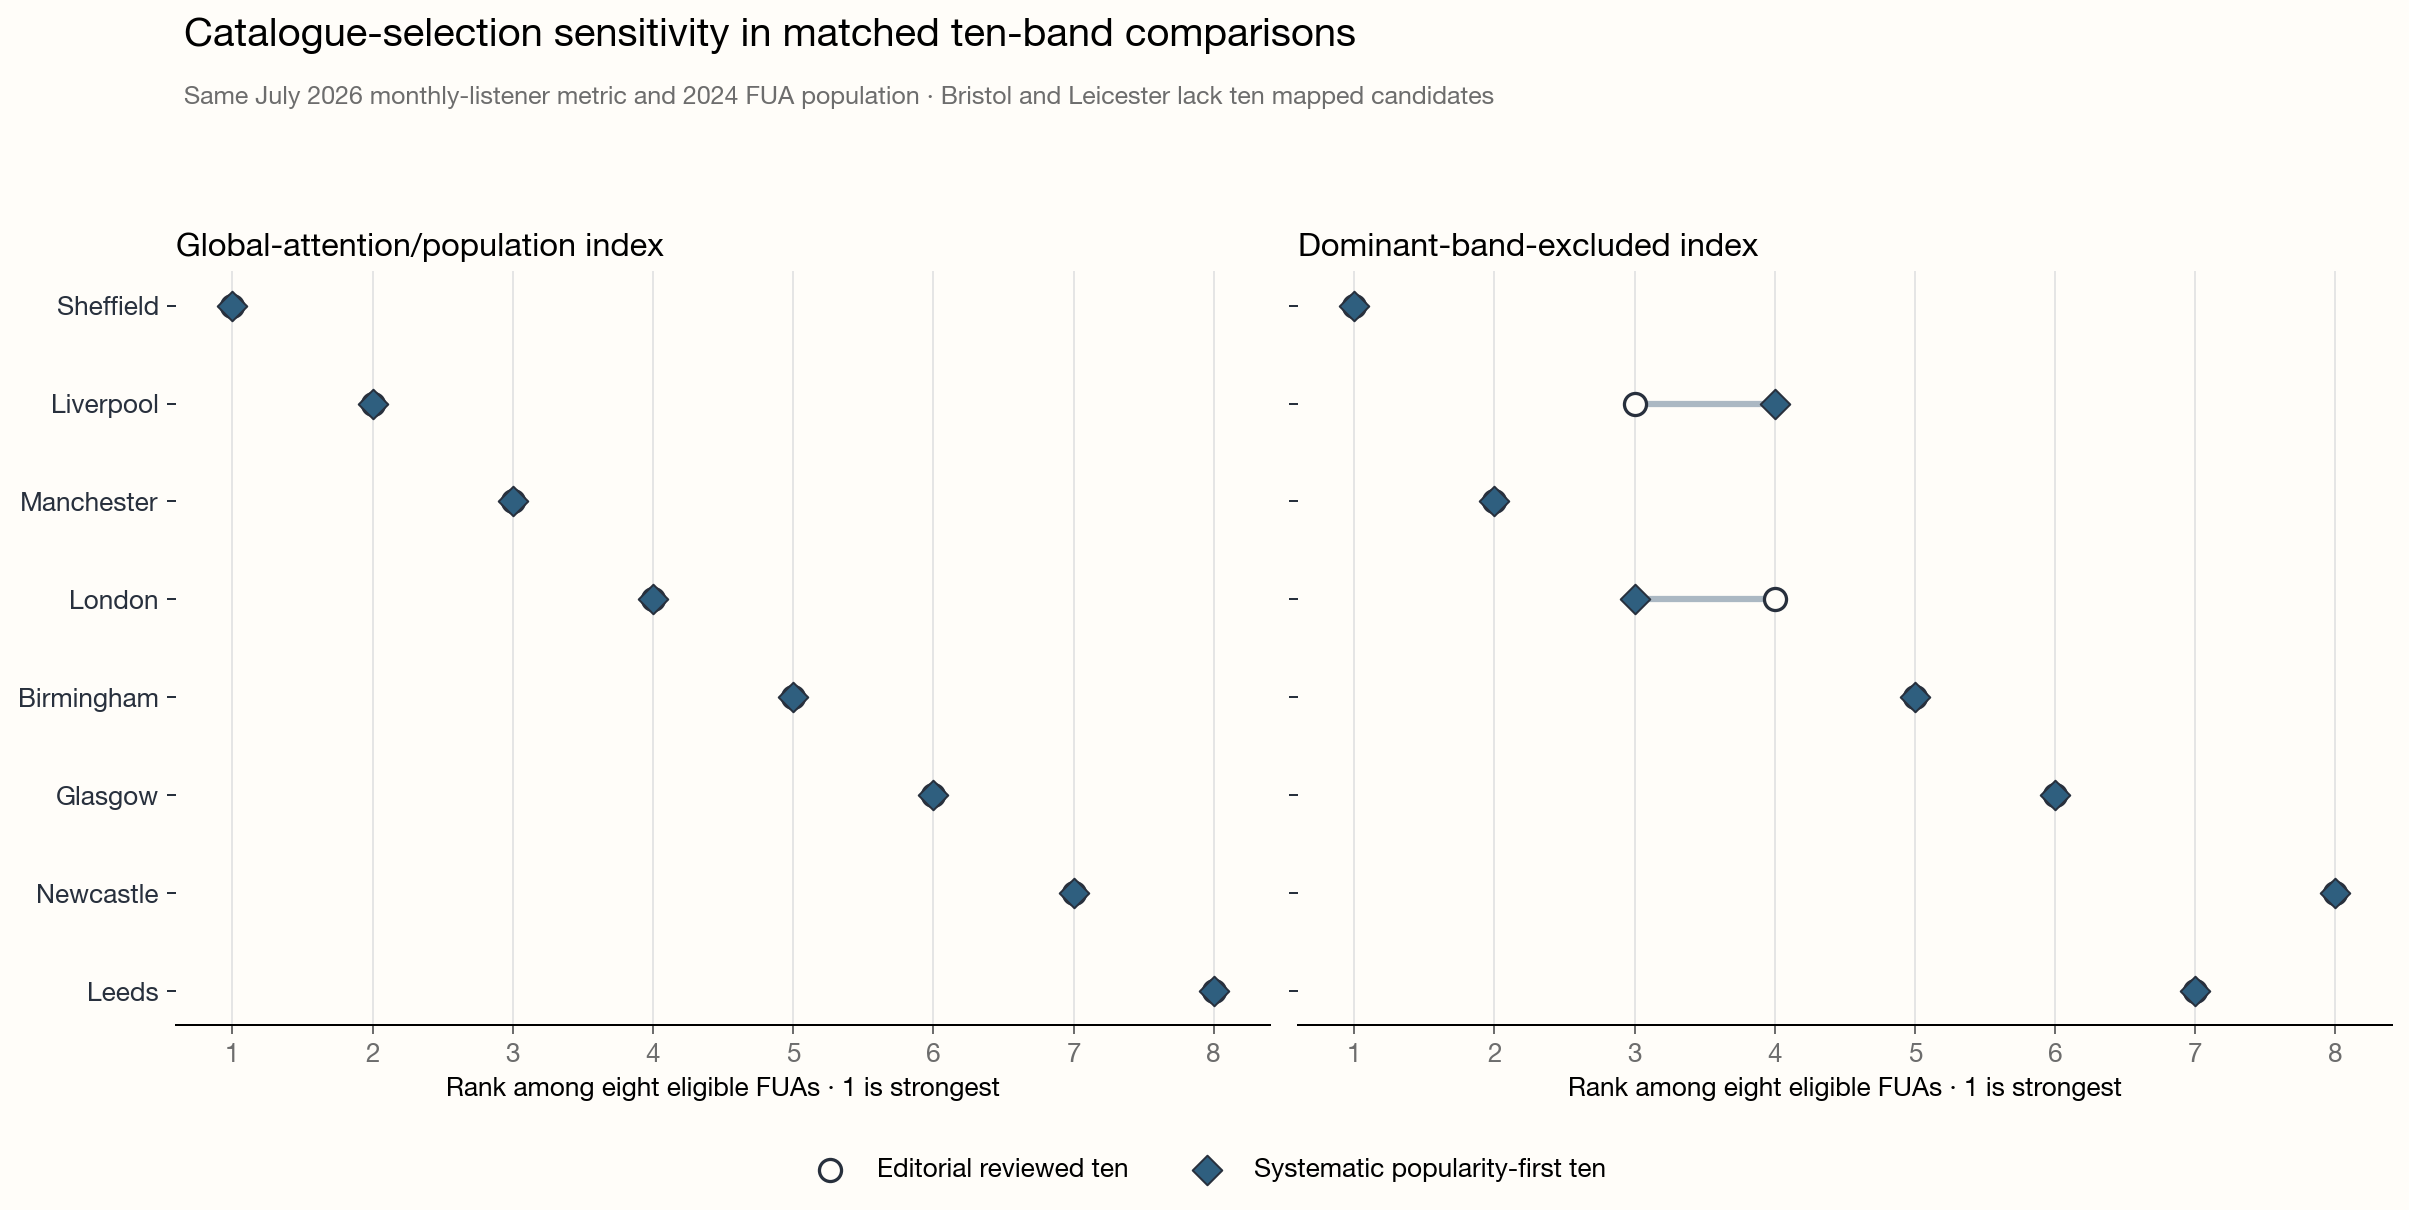

In [5]:
apply_chart_style()
ordered = comparison.sort_values("index_rank_editorial", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.8), sharey=True)

panels = [
    ("index_rank_editorial", "index_rank_systematic", "Global-attention/population index"),
    ("dominant_band_excluded_rank_editorial", "dominant_band_excluded_rank_systematic", "Dominant-band-excluded index"),
]
for ax, (editorial_column, systematic_column, title) in zip(axes, panels):
    y = np.arange(len(ordered))
    ax.hlines(
        y,
        ordered[[editorial_column, systematic_column]].min(axis=1),
        ordered[[editorial_column, systematic_column]].max(axis=1),
        color=HOUSE["gray_blue"],
        linewidth=2.5,
    )
    ax.scatter(
        ordered[editorial_column], y,
        s=78, facecolor=HOUSE["page"], edgecolor=HOUSE["ink_soft"], linewidth=1.3,
        label="Editorial reviewed ten", zorder=3,
    )
    ax.scatter(
        ordered[systematic_column], y,
        s=70, marker="D", facecolor=HOUSE["blue"], edgecolor=HOUSE["ink_soft"], linewidth=0.8,
        label="Systematic popularity-first ten", zorder=3,
    )
    ax.set_yticks(y, ordered["study_city_label"])
    ax.set_xticks(range(1, 9))
    ax.set_xlim(0.6, 8.4)
    ax.set_xlabel("Rank among eight eligible FUAs · 1 is strongest")
    ax.set_title(title, loc="left", fontsize=13, fontweight="normal")
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)
    ax.spines[["top", "right", "left"]].set_visible(False)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.01))
fig.suptitle(
    "Catalogue-selection sensitivity in matched ten-band comparisons",
    x=0.08, ha="left", fontsize=16, fontweight="normal",
)
fig.text(
    0.08, 0.91,
    "Same July 2026 monthly-listener metric and 2024 FUA population · Bristol and Leicester lack ten mapped candidates",
    color=HOUSE["secondary"], fontsize=10,
)
fig.tight_layout(rect=(0, 0.07, 1, 0.88))
chart_path = ARTIFACT_DIR / "chart_01_catalogue_rank_comparison.png"
fig.savefig(chart_path, dpi=180, bbox_inches="tight", facecolor=HOUSE["page"])
plt.close(fig)
display(Image(filename=str(chart_path)))


## Takeaways

- Band choice still matters: 67 of the 80 selections overlap, and city-level
  overlap ranges from six to ten bands.
- The primary ranking is stable within this matched alternative. All eight
  FUAs retain the same positions.
- Dominant-band-excluded ranks move more. The lower correlation reinforces that
  this is sensitivity within selected catalogues, not a direct measure of the
  depth of an entire local music scene.
- Bristol and Leicester cannot enter the equal-count comparison because the
  mapped popularity-first pool contains fewer than ten bands. The experiment
  therefore does not establish representativeness for all ten FUAs.
- The population division remains a comparative index. It does not imply that
  Spotify listeners live in the FUA, that artist audiences are mutually
  exclusive, or that 2024 population caused decades of band production.

This focused experiment can be shared with caveats. It strengthens the
narrow top-four result against one systematic alternative, but it does not
turn either catalogue into a census.
